# 1차 : 카테고리 통합 후 회귀

- 카테고리별로 학습 > 성능이 너무 안좋은게 많았음(R^2 음수)
- 카테고리를 통합하면서 할인율의 영향력이 상쇄된게 아닐까 싶어서 2차 시도는 다시 카테고리 통합 전으로 돌아감

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime

# 불필요한 경고문 생략(선택)
import warnings
warnings.filterwarnings('ignore')

# 모든 컬럼 출력설정(선택)
pd.set_option('display.max_columns', None)

df = pd.read_csv('카테고리별 분류 파일/여름_캐주얼셔츠.csv')
df.isna().sum()

기획년도           0
주차_날짜          0
카테고리_통합        0
시즌이월           0
시즌             0
총입고수량          0
판매수량           0
판매액            0
평균택가           0
평균원가           0
주차별_평균_실판매가    7
월별_평균_실판매가     4
시즌별_평균_실판매가    0
총입고원가          0
총입고택가          0
매출원가계          0
판매택가계          0
실판매가           0
할인율            0
누적판매수량         0
누적판매액          0
누적매출원가         0
누적판매택가         0
누적판매율          0
ROI            0
악천후일수          0
평균기온(도)        0
주차             0
dtype: int64

In [ ]:
import pandas as pd
import numpy as np

columns = ['기획년도', '주차', '평균기온(도)', '할인율', '판매수량']
df = df[columns]

# #결측치 있으면 전 행으로 채워넣기
# df.fillna(method='ffill', inplace=True)

train_df = df[df['기획년도'] < 2024]
test_df = df[df['기획년도'] == 2024]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, learning_rate=0.1, max_depth=4, n_jobs=-1, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train) 
    y_pred = model.predict(X_test) 
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

import pprint
pprint.pprint(results)

{'RandomForest': {'MAE': 1761.010511438024,
                  'MSE': 4771716.642133395,
                  'R2 Score': -5.926034237110061,
                  'RMSE': 2184.425929651403},
 'XGBoost': {'MAE': 1493.7579083564954,
             'MSE': 3646622.0080363415,
             'R2 Score': -4.2929858941009345,
             'RMSE': 1909.613051912963}}


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'XGBoost': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8, 10]
    },
    'RandomForest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [4, 6, 8, 10, None]
    }
}

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42),
    'RandomForest': RandomForestRegressor(n_jobs=-1, random_state=42)
}

best_params = {}
best_scores = {}

for name, model in models.items():
    print(f"{name} 하이퍼파라미터 튜닝 중...")
    
    grid_search = GridSearchCV(model, param_grids[name], scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_params[name] = grid_search.best_params_
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    best_scores[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

print("\n최적 하이퍼파라미터:")
print(best_params)

print("\n최적 모델 성능 평가:")
import pprint
pprint.pprint(best_scores)

XGBoost 하이퍼파라미터 튜닝 중...
RandomForest 하이퍼파라미터 튜닝 중...

최적 하이퍼파라미터:
{'XGBoost': {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100}, 'RandomForest': {'max_depth': 4, 'n_estimators': 200}}

최적 모델 성능 평가:
{'RandomForest': {'MAE': 1741.8741763200123,
                  'MSE': 4659219.987882014,
                  'R2 Score': -5.762747995000544,
                  'RMSE': 2158.522640113375},
 'XGBoost': {'MAE': 1443.380382048778,
             'MSE': 3466673.910809822,
             'R2 Score': -4.031795472337654,
             'RMSE': 1861.900617866008}}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 랜덤 서치용 하이퍼파라미터 범위 정의
param_distributions = {
    'XGBoost': {
        'n_estimators': randint(100, 1000),         # 50 ~ 500 사이 정수
        'learning_rate': uniform(0.01, 0.3),      # 0.01 ~ 0.31 사이 실수
        'max_depth': randint(3, 15)               # 3 ~ 10 사이 정수
    },
    'RandomForest': {
        'n_estimators': randint(100, 1000),
        'max_depth': randint(3, 15)
    }
}

best_params = {}
best_scores = {}

for name, model in models.items():
    print(f"{name} 랜덤 서치 중...")
    
    random_search = RandomizedSearchCV(
        model, 
        param_distributions[name], 
        n_iter=50,  # 몇 번 시도할지 설정 (ex: 20회)
        scoring='neg_mean_absolute_error',
        cv=3,
        n_jobs=-1,
        random_state=42
    )
    
    random_search.fit(X_train, y_train)
    best_params[name] = random_search.best_params_
    
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    best_scores[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

print("\n최적 하이퍼파라미터:")
print(best_params)

print("\n최적 모델 성능 평가:")
pprint.pprint(best_scores)


XGBoost 랜덤 서치 중...
RandomForest 랜덤 서치 중...

최적 하이퍼파라미터:
{'XGBoost': {'learning_rate': 0.2787290787020558, 'max_depth': 3, 'n_estimators': 663}, 'RandomForest': {'max_depth': 3, 'n_estimators': 574}}

최적 모델 성능 평가:
{'RandomForest': {'MAE': 1932.907901435042,
                  'MSE': 5411535.609625274,
                  'R2 Score': -6.854716387947064,
                  'RMSE': 2326.270751573272},
 'XGBoost': {'MAE': 1438.5655150046716,
             'MSE': 3651041.044651071,
             'R2 Score': -4.299400021590905,
             'RMSE': 1910.7697518673126}}


In [ ]:
best_model = xgb.XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42, learning_rate=0.2, max_depth= 4, n_estimators= 100)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'XGBoost Results - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')

XGBoost Results - RMSE: 1861.9006, MAE: 1443.3804, R2: -4.0318


In [ ]:
importances = best_model.feature_importances_

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(X_train.shape[1])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

   Feature  Importance
2  평균기온(도)    0.453535
0     기획년도    0.251162
1       주차    0.238618
3      할인율    0.056685


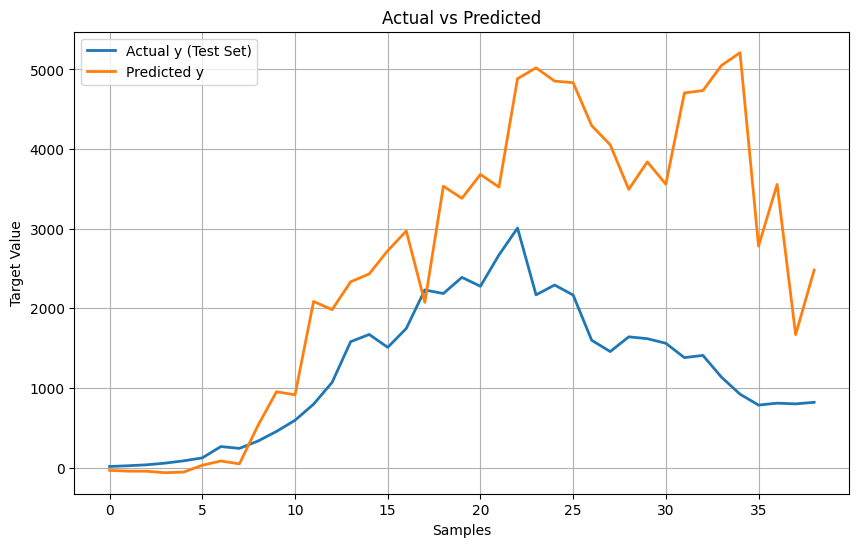

In [ ]:
import matplotlib.pyplot as plt

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual y (Test Set)', linewidth=2)
plt.plot(y_pred, label='Predicted y', linewidth=2)
plt.legend()
plt.title('Actual vs Predicted')
plt.xlabel('Samples')
plt.ylabel('Target Value')
plt.grid(True)
plt.show()

# 2차 : 소품종 기준 카테고리로 회귀

- 카테고리별로 회귀, 시점을 바꿔가면서 예측해봄(여름 제품은 6월 말 시점, 겨울은 10월 말 시점 등등)
- 엄청 잘 맞는 카테고리가 있고(R^2 0.9), 여전히 너무 안 맞는 것도 있고(R^2 음수)

## 예시) 겨울_사파리_패딩사파리_ZB

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime

# 불필요한 경고문 생략(선택)
import warnings
warnings.filterwarnings('ignore')

# 모든 컬럼 출력설정(선택)
pd.set_option('display.max_columns', None)

df = pd.read_csv('model_df_할인율NaN&음수처리.csv')
df.head(2)

,기획년도,주차,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,판매수량,판매액,평균택가,평균원가,총입고원가,총입고택가,매출원가계,판매택가계,주차별_평균_실판매가,월,월별_평균_실판매가,시즌별_평균_실판매가,실판매가,할인율,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도)
0,2021,2021-01-03,봄_가죽&FUR_가죽점퍼_ZA,ZA,01_시즌,봄,가죽&FUR,가죽점퍼,1:남성,1600,53,52297400,999000,204500,327200000,1598400000,10838500,52947000,987706.0,1,530682.0,455693,986743.0,1.0,53,52297400,10838500,52947000,3.31,0.11,4,0,0,0,3,0,0,0,-9.1
1,2021,2021-01-03,사계절_우븐 셔츠_드레스셔츠_ZC,ZC,01_시즌,사계절,우븐 셔츠,드레스셔츠,1:남성,1000,15,590520,39900,7535,7535000,39900000,113025,598500,39368.0,1,30812.0,28709,39368.0,1.0,15,590520,113025,598500,1.50,0.06,4,0,0,0,3,0,0,0,-9.1


In [ ]:
df.rename(columns={"주차": "주차_날짜"}, inplace=True)
df["주차_날짜"] = pd.to_datetime(df["주차_날짜"])
df["주차"] = df["주차_날짜"].dt.strftime("%U").astype(int)
df[df['주차']==1].head(2)

,기획년도,주차_날짜,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,판매수량,판매액,평균택가,평균원가,총입고원가,총입고택가,매출원가계,판매택가계,주차별_평균_실판매가,월,월별_평균_실판매가,시즌별_평균_실판매가,실판매가,할인율,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도),주차
0,2021,2021-01-03,봄_가죽&FUR_가죽점퍼_ZA,ZA,01_시즌,봄,가죽&FUR,가죽점퍼,1:남성,1600,53,52297400,999000,204500,327200000,1598400000,10838500,52947000,987706.0,1,530682.0,455693,986743.0,1.0,53,52297400,10838500,52947000,3.31,0.11,4,0,0,0,3,0,0,0,-9.1,1
1,2021,2021-01-03,사계절_우븐 셔츠_드레스셔츠_ZC,ZC,01_시즌,사계절,우븐 셔츠,드레스셔츠,1:남성,1000,15,590520,39900,7535,7535000,39900000,113025,598500,39368.0,1,30812.0,28709,39368.0,1.0,15,590520,113025,598500,1.50,0.06,4,0,0,0,3,0,0,0,-9.1,1


In [ ]:
filtered_df= df[df['카테고리']=='겨울_사파리_패딩사파리_ZB']
filtered_df.head(2)

,기획년도,주차_날짜,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,판매수량,판매액,평균택가,평균원가,총입고원가,총입고택가,매출원가계,판매택가계,주차별_평균_실판매가,월,월별_평균_실판매가,시즌별_평균_실판매가,실판매가,할인율,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도),주차
1283,2021,2021-09-05,겨울_사파리_패딩사파리_ZB,ZB,01_시즌,겨울,사파리,패딩사파리,1:남성,6290,80,24965400,399000,30461,191599690,2509710000,2436880,31920000,314364.0,9,255224.0,217449,312068.0,22.000000,80,24965400,2436880,31920000,1.27,0.11,4,1,2,0,0,0,0,0,22.6,36
1338,2021,2021-09-12,겨울_사파리_패딩사파리_ZB,ZB,01_시즌,겨울,사파리,패딩사파리,1:남성,6290,-24,-13188700,399000,30461,191599690,2509710000,-731064,-9576000,492244.0,9,255224.0,217449,255224.0,36.034085,56,11776700,1705816,22344000,0.89,0.05,7,0,0,0,0,0,0,0,23.9,37


In [ ]:
columns = ['기획년도', '주차', '평균기온(도)', '할인율', '판매수량']
model_df = filtered_df[columns]

### 2024년 전체 예측

In [ ]:
# #결측치 있으면 전 행으로 채워넣기
# df.fillna(method='ffill', inplace=True)

train_df = model_df[model_df['기획년도'] < 2024]
test_df = model_df[model_df['기획년도'] == 2024]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, learning_rate=0.1, max_depth=4, n_jobs=-1, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1)
}

results = {}

# 모델 학습 및 평가
for name, model in models.items():
    model.fit(X_train, y_train) 
    y_pred = model.predict(X_test) 
    
    # 성능 평가
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

import pprint
pprint.pprint(results)

{'RandomForest': {'MAE': 230.29263587625763,
                  'MSE': 112695.1585460847,
                  'R2 Score': 0.9171411996827851,
                  'RMSE': 335.7009957478302},
 'XGBoost': {'MAE': 336.4541427067348,
             'MSE': 243638.1994493126,
             'R2 Score': 0.820865694868684,
             'RMSE': 493.59720364818986}}


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'XGBoost': {
        'n_estimators': [50,100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8, 10]
    },
    'RandomForest': {
        'n_estimators': [50,100, 200, 500],
        'max_depth': [4, 6, 8, 10, None]
    }
}

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42),
    'RandomForest': RandomForestRegressor(n_jobs=-1, random_state=42)
}

best_params = {}
best_scores = {}

for name, model in models.items():
    print(f"{name} 하이퍼파라미터 튜닝 중...")
    
    grid_search = GridSearchCV(model, param_grids[name], scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_params[name] = grid_search.best_params_
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    best_scores[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

print("\n최적 하이퍼파라미터:")
print(best_params)

print("\n최적 모델 성능 평가:")
import pprint
pprint.pprint(best_scores)

XGBoost 하이퍼파라미터 튜닝 중...
RandomForest 하이퍼파라미터 튜닝 중...

최적 하이퍼파라미터:
{'XGBoost': {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 500}, 'RandomForest': {'max_depth': 4, 'n_estimators': 500}}

최적 모델 성능 평가:
{'RandomForest': {'MAE': 245.27629514168552,
                  'MSE': 126997.76831267106,
                  'R2 Score': 0.9066252458303399,
                  'RMSE': 356.3674624775262},
 'XGBoost': {'MAE': 307.811731338501,
             'MSE': 221580.26574533505,
             'R2 Score': 0.8370837289685326,
             'RMSE': 470.723130667418}}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 랜덤 서치용 하이퍼파라미터 범위 정의
param_distributions = {
    'XGBoost': {
        'n_estimators': randint(50, 1000),         # 50 ~ 500 사이 정수
        'learning_rate': uniform(0.01, 0.3),      # 0.01 ~ 0.31 사이 실수
        'max_depth': randint(3, 15)               # 3 ~ 10 사이 정수
    },
    'RandomForest': {
        'n_estimators': randint(50, 1000),
        'max_depth': randint(3, 15)
    }
}

best_params = {}
best_scores = {}

for name, model in models.items():
    print(f"{name} 랜덤 서치 중...")
    
    random_search = RandomizedSearchCV(
        model, 
        param_distributions[name], 
        n_iter=50,  # 몇 번 시도할지 설정 (ex: 20회)
        scoring='neg_mean_absolute_error',
        cv=3,
        n_jobs=-1,
        random_state=42
    )
    
    random_search.fit(X_train, y_train)
    best_params[name] = random_search.best_params_
    
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    best_scores[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

print("\n최적 하이퍼파라미터:")
print(best_params)

print("\n최적 모델 성능 평가:")
pprint.pprint(best_scores)


XGBoost 랜덤 서치 중...
RandomForest 랜덤 서치 중...

최적 하이퍼파라미터:
{'XGBoost': {'learning_rate': 0.2287021504122962, 'max_depth': 3, 'n_estimators': 428}, 'RandomForest': {'max_depth': 3, 'n_estimators': 524}}

최적 모델 성능 평가:
{'RandomForest': {'MAE': 225.64897662683794,
                  'MSE': 98813.56192342135,
                  'R2 Score': 0.9273476047979705,
                  'RMSE': 314.3462452828431},
 'XGBoost': {'MAE': 244.85154759032386,
             'MSE': 161563.668903465,
             'R2 Score': 0.8812107640390384,
             'RMSE': 401.94983381445127}}


In [ ]:
best_model = RandomForestRegressor(n_jobs=-1, random_state=42, max_depth=3, n_estimators=524)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RandomForest Results - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')

RandomForest Results - RMSE: 314.3462, MAE: 225.6490, R2: 0.9273


In [ ]:
importances = best_model.feature_importances_

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(X_train.shape[1])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

   Feature  Importance
1       주차    0.596321
2  평균기온(도)    0.199734
3      할인율    0.178814
0     기획년도    0.025132


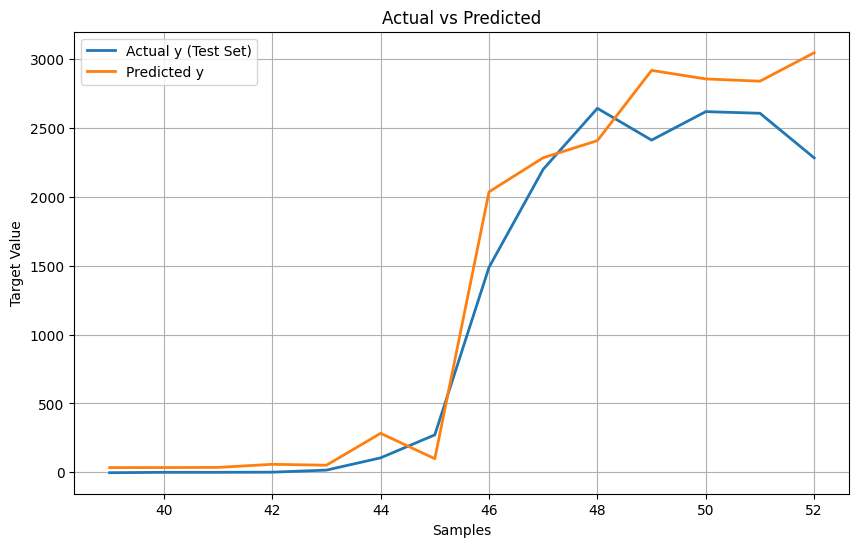

In [ ]:
import matplotlib.pyplot as plt

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(X_test['주차'],y_test.values, label='Actual y (Test Set)', linewidth=2)
plt.plot(X_test['주차'],y_pred, label='Predicted y', linewidth=2)
plt.legend()
plt.title('Actual vs Predicted')
plt.xlabel('Samples')
plt.ylabel('Target Value')
plt.grid(True)
plt.show()

### 10월 말 시점 11월 예측

In [ ]:
train_df = filtered_df[filtered_df['주차_날짜'] <= '2024-10-27']
test_df = filtered_df[(filtered_df['주차_날짜'] > '2024-10-27') & (filtered_df['주차_날짜']<='2024-11-25')]

train_df = train_df[columns]
test_df = test_df[columns]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, learning_rate=0.1, max_depth=4, n_jobs=-1, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1)
}

results = {}

# 모델 학습 및 평가
for name, model in models.items():
    model.fit(X_train, y_train) 
    y_pred = model.predict(X_test) 
    
    # 성능 평가
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

import pprint
pprint.pprint(results)

{'RandomForest': {'MAE': 266.9154414927017,
                  'MSE': 134305.15530228656,
                  'R2 Score': 0.8216048813668533,
                  'RMSE': 366.47667770580784},
 'XGBoost': {'MAE': 434.7765645980835,
             'MSE': 291633.885142499,
             'R2 Score': 0.612627963384248,
             'RMSE': 540.031374220516}}


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'XGBoost': {
        'n_estimators': [50,100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8, 10]
    },
    'RandomForest': {
        'n_estimators': [50,100, 200, 500],
        'max_depth': [4, 6, 8, 10, None]
    }
}

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42),
    'RandomForest': RandomForestRegressor(n_jobs=-1, random_state=42)
}

best_params = {}
best_scores = {}

for name, model in models.items():
    print(f"{name} 하이퍼파라미터 튜닝 중...")
    
    grid_search = GridSearchCV(model, param_grids[name], scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_params[name] = grid_search.best_params_
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    best_scores[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

print("\n최적 하이퍼파라미터:")
print(best_params)

print("\n최적 모델 성능 평가:")
import pprint
pprint.pprint(best_scores)

XGBoost 하이퍼파라미터 튜닝 중...
RandomForest 하이퍼파라미터 튜닝 중...

최적 하이퍼파라미터:
{'XGBoost': {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 500}, 'RandomForest': {'max_depth': 4, 'n_estimators': 500}}

최적 모델 성능 평가:
{'RandomForest': {'MAE': 271.8664675167561,
                  'MSE': 122900.51672315423,
                  'R2 Score': 0.8367534573668829,
                  'RMSE': 350.5716998320803},
 'XGBoost': {'MAE': 268.82986068725586,
             'MSE': 130074.18656768563,
             'R2 Score': 0.8272248009272263,
             'RMSE': 360.65799113243787}}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 랜덤 서치용 하이퍼파라미터 범위 정의
param_distributions = {
    'XGBoost': {
        'n_estimators': randint(50, 1000),         # 50 ~ 500 사이 정수
        'learning_rate': uniform(0.01, 0.3),      # 0.01 ~ 0.31 사이 실수
        'max_depth': randint(3, 15)               # 3 ~ 10 사이 정수
    },
    'RandomForest': {
        'n_estimators': randint(50, 1000),
        'max_depth': randint(3, 15)
    }
}

best_params = {}
best_scores = {}

for name, model in models.items():
    print(f"{name} 랜덤 서치 중...")
    
    random_search = RandomizedSearchCV(
        model, 
        param_distributions[name], 
        n_iter=50,  # 몇 번 시도할지 설정 (ex: 20회)
        scoring='neg_mean_absolute_error',
        cv=3,
        n_jobs=-1,
        random_state=42
    )
    
    random_search.fit(X_train, y_train)
    best_params[name] = random_search.best_params_
    
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    best_scores[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

print("\n최적 하이퍼파라미터:")
print(best_params)

print("\n최적 모델 성능 평가:")
pprint.pprint(best_scores)


XGBoost 랜덤 서치 중...
RandomForest 랜덤 서치 중...

최적 하이퍼파라미터:
{'XGBoost': {'learning_rate': 0.1212454756594799, 'max_depth': 10, 'n_estimators': 854}, 'RandomForest': {'max_depth': 3, 'n_estimators': 981}}

최적 모델 성능 평가:
{'RandomForest': {'MAE': 248.28966190051844,
                  'MSE': 89458.6630149836,
                  'R2 Score': 0.8811736692802217,
                  'RMSE': 299.09641090287863},
 'XGBoost': {'MAE': 328.4841365814209,
             'MSE': 188849.09428860561,
             'R2 Score': 0.7491551496772324,
             'RMSE': 434.56770967089307}}


In [ ]:
best_model = RandomForestRegressor(n_estimators=981, max_depth=3, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RandomForest Results - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')

RandomForest Results - RMSE: 299.0964, MAE: 248.2897, R2: 0.8812


In [ ]:
importances = best_model.feature_importances_

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(X_train.shape[1])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

   Feature  Importance
1       주차    0.604686
2  평균기온(도)    0.192541
3      할인율    0.178969
0     기획년도    0.023804


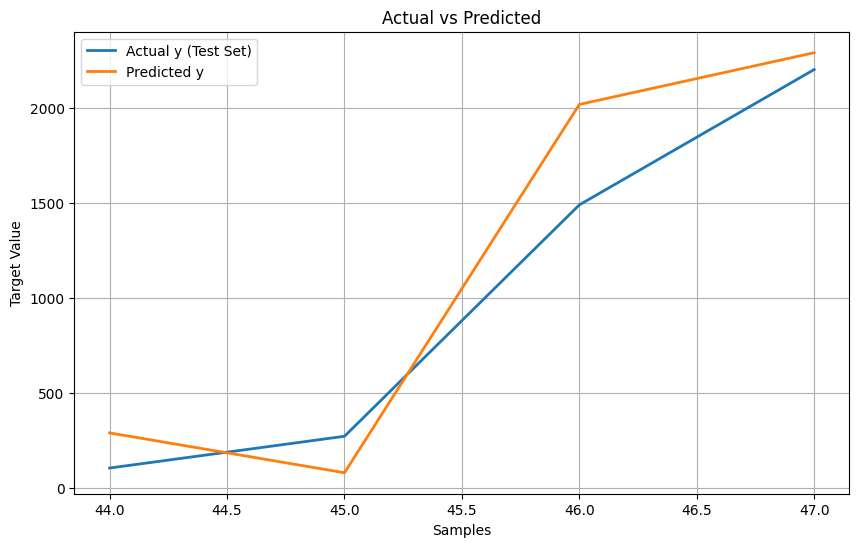

In [ ]:
import matplotlib.pyplot as plt

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(X_test['주차'],y_test.values, label='Actual y (Test Set)', linewidth=2)
plt.plot(X_test['주차'],y_pred, label='Predicted y', linewidth=2)
plt.legend()
plt.title('Actual vs Predicted')
plt.xlabel('Samples')
plt.ylabel('Target Value')
plt.grid(True)
plt.show()

# 3차 : 할인율 변화량에 따른 판매량 변화량 예측 

- 할인율에 따른 판매량 예측 자체가 잘 안된다?
- 그럼 할인율 변화량에 따른 판매량 변화량은 예측이 잘 되려나?
- 이 또한 카레고리 바이 카테고리

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 할인율 변화량과 판매수량 변화량 생성
model_df['할인율변화량'] = model_df['할인율'].diff()
model_df['판매수량변화량'] = model_df['판매수량'].diff()

model_df = model_df.dropna()

X = model_df[['할인율변화량']]
y = model_df['판매수량변화량']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_df = pd.DataFrame(results).T
print(results_df)

                    RMSE         MAE        R2
RandomForest  567.434314  391.339954  0.688794
XGBoost       588.749374  425.202727  0.664975


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("coef(기울기):", lr.coef_)
print("intercept(절편):", lr.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

coef(기울기): [37.70040877]
intercept(절편): 27.780360461678484
R2 Score: 0.8316185942402636
RMSE: 417.38696772774676
MAE: 344.64313319827227
MSE: 174211.88082896313


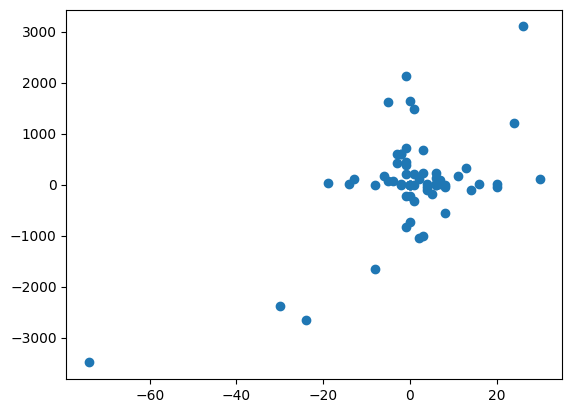

In [ ]:
plt.scatter(model_df['할인율변화량'],model_df['판매수량변화량'])

# 4차 : 전체 카테고리 통으로 회귀

- 튜터님 피드백 받다가, 모든 카테고리마다 회귀 모델을 따로 만든다 > 그냥 카테고리도 변수로 넣고 하나로 만들면 안됨?
- 시점별로 학습 > 성능 자체는 0.7 0.8 이정도 왔다갔다 

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 불필요한 경고문 생략(선택)
import warnings
warnings.filterwarnings('ignore')

# 모든 컬럼 출력설정(선택)
pd.set_option('display.max_columns', None)

df = pd.read_csv('model_df_할인율NaN&음수처리.csv')
df.head(2)

,기획년도,주차,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,판매수량,판매액,평균택가,평균원가,총입고원가,총입고택가,매출원가계,판매택가계,주차별_평균_실판매가,월,월별_평균_실판매가,시즌별_평균_실판매가,실판매가,할인율,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도)
0,2021,2021-01-03,봄_가죽&FUR_가죽점퍼_ZA,ZA,01_시즌,봄,가죽&FUR,가죽점퍼,1:남성,1600,53,52297400,999000,204500,327200000,1598400000,10838500,52947000,987706.0,1,530682.0,455693,986743.0,1.0,53,52297400,10838500,52947000,3.31,0.11,4,0,0,0,3,0,0,0,-9.1
1,2021,2021-01-03,사계절_우븐 셔츠_드레스셔츠_ZC,ZC,01_시즌,사계절,우븐 셔츠,드레스셔츠,1:남성,1000,15,590520,39900,7535,7535000,39900000,113025,598500,39368.0,1,30812.0,28709,39368.0,1.0,15,590520,113025,598500,1.50,0.06,4,0,0,0,3,0,0,0,-9.1


In [ ]:
df.rename(columns={"주차": "주차_날짜"}, inplace=True)
df["주차_날짜"] = pd.to_datetime(df["주차_날짜"])
df["주차"] = df["주차_날짜"].dt.strftime("%U").astype(int)
df[df['주차']==1].head(2)

,기획년도,주차_날짜,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,판매수량,판매액,평균택가,평균원가,총입고원가,총입고택가,매출원가계,판매택가계,주차별_평균_실판매가,월,월별_평균_실판매가,시즌별_평균_실판매가,실판매가,할인율,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도),주차
0,2021,2021-01-03,봄_가죽&FUR_가죽점퍼_ZA,ZA,01_시즌,봄,가죽&FUR,가죽점퍼,1:남성,1600,53,52297400,999000,204500,327200000,1598400000,10838500,52947000,987706.0,1,530682.0,455693,986743.0,1.0,53,52297400,10838500,52947000,3.31,0.11,4,0,0,0,3,0,0,0,-9.1,1
1,2021,2021-01-03,사계절_우븐 셔츠_드레스셔츠_ZC,ZC,01_시즌,사계절,우븐 셔츠,드레스셔츠,1:남성,1000,15,590520,39900,7535,7535000,39900000,113025,598500,39368.0,1,30812.0,28709,39368.0,1.0,15,590520,113025,598500,1.50,0.06,4,0,0,0,3,0,0,0,-9.1,1


In [ ]:
columns = ['기획년도', '주차', '평균기온(도)', '할인율', '카테고리','판매수량']
model_df = df[columns]

## 24년 전체

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

train_df = model_df[model_df['기획년도'] < 2024]
test_df = model_df[model_df['기획년도'] == 2024]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

# 원-핫 인코딩
categorical_features = ['카테고리']
numerical_features = ['기획년도', '주차', '평균기온(도)', '할인율']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} 모델 성능:")
    print(f" - R^2: {r2:.4f}")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - MAE : {mae:.2f}")
    print('-' * 30)

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


Random Forest 모델 성능:
 - R^2: 0.6479
 - RMSE: 386.86
 - MAE : 208.18
------------------------------
XGBoost 모델 성능:
 - R^2: 0.6658
 - RMSE: 376.85
 - MAE : 228.76
------------------------------


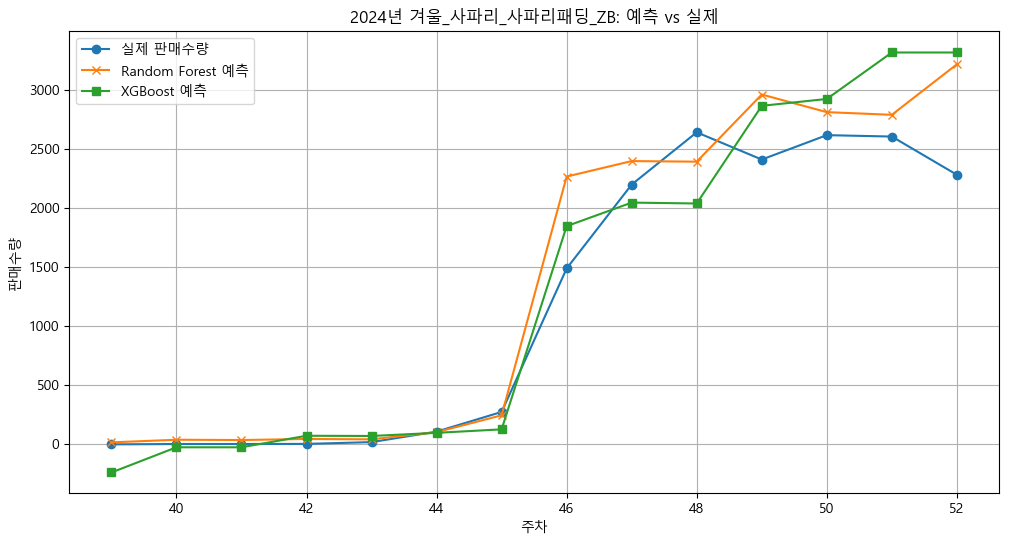

In [ ]:


target_df = model_df[
    (model_df['기획년도'] == 2024) &
    (model_df['카테고리'] == '겨울_사파리_패딩사파리_ZB')
]

X_target = target_df.drop(columns=['판매수량'])

y_actual = target_df['판매수량']

rf_preds = rf_model.predict(X_target)
xgb_preds = xgb_model.predict(X_target)

result_df = X_target.copy()
result_df['실제값'] = y_actual.values
result_df['RandomForest_예측값'] = rf_preds
result_df['XGBoost_예측값'] = xgb_preds

result_df = result_df.sort_values(by='주차').reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['주차'], result_df['실제값'], label='실제 판매수량', marker='o')
plt.plot(result_df['주차'], result_df['RandomForest_예측값'], label='Random Forest 예측', marker='x')
plt.plot(result_df['주차'], result_df['XGBoost_예측값'], label='XGBoost 예측', marker='s')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('2024년 겨울_사파리_사파리패딩_ZB: 예측 vs 실제')
plt.legend()
plt.grid(True)
plt.show()

## 10월 시점

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# 데이터 분리
train_df = df[df['주차_날짜'] <= '2024-10-27']
test_df = df[(df['주차_날짜'] > '2024-10-27') & (df['주차_날짜']<='2024-11-25')]

train_df = train_df[columns]
test_df = test_df[columns]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

# 전처리: 카테고리 컬럼 원-핫 인코딩
categorical_features = ['카테고리']
numerical_features = ['기획년도', '주차', '평균기온(도)', '할인율']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# 모델 1: Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 모델 2: XGBoost
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

# 학습
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 예측
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# 평가
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} 모델 성능:")
    print(f" - R^2: {r2:.4f}")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - MAE : {mae:.2f}")
    print('-' * 30)

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


Random Forest 모델 성능:
 - R^2: 0.8549
 - RMSE: 229.81
 - MAE : 146.18
------------------------------
XGBoost 모델 성능:
 - R^2: 0.8335
 - RMSE: 246.16
 - MAE : 173.28
------------------------------


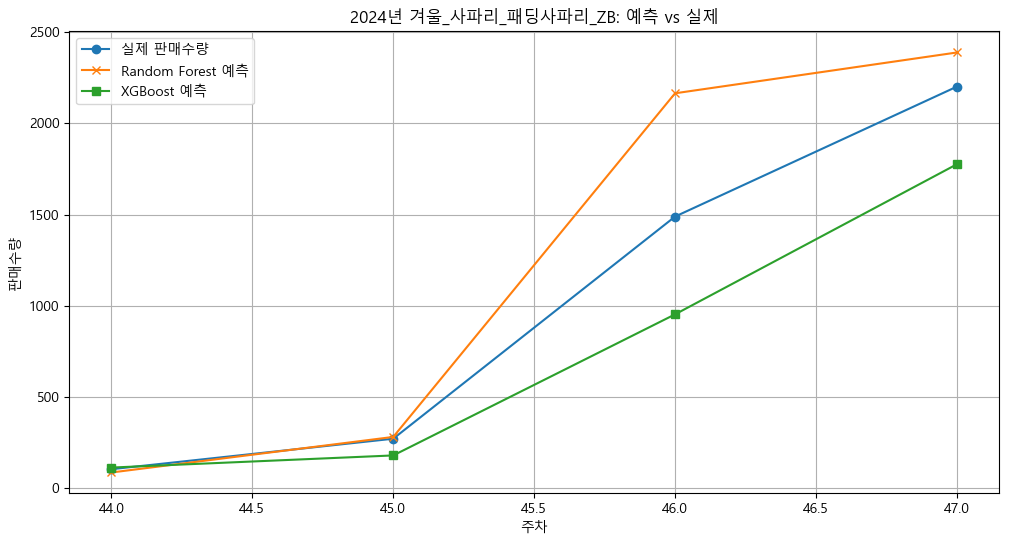

In [ ]:
target_df = model_df[
    (model_df['기획년도'] == 2024) &
    (model_df['주차'].between(44, 47)) &
    (model_df['카테고리'] == '겨울_사파리_패딩사파리_ZB')
]

X_target = target_df.drop(columns=['판매수량'])

y_actual = target_df['판매수량']

rf_preds = rf_model.predict(X_target)
xgb_preds = xgb_model.predict(X_target)

result_df = X_target.copy()
result_df['실제값'] = y_actual.values
result_df['RandomForest_예측값'] = rf_preds
result_df['XGBoost_예측값'] = xgb_preds

result_df = result_df.sort_values(by='주차').reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['주차'], result_df['실제값'], label='실제 판매수량', marker='o')
plt.plot(result_df['주차'], result_df['RandomForest_예측값'], label='Random Forest 예측', marker='x')
plt.plot(result_df['주차'], result_df['XGBoost_예측값'], label='XGBoost 예측', marker='s')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('2024년 겨울_사파리_패딩사파리_ZB: 예측 vs 실제')
plt.legend()
plt.grid(True)
plt.show()

### 최적 파라미터 찾기

In [ ]:
from sklearn.model_selection import GridSearchCV

# rf_param_grid = {
#     'regressor__n_estimators': [100, 200],
#     'regressor__max_depth': [None, 10, 20],
#     'regressor__min_samples_split': [2, 5],
#     'regressor__min_samples_leaf': [1, 2]
# }

rf_param_grid = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['auto', 'sqrt']
}

rf_grid = GridSearchCV(
    rf_model, 
    rf_param_grid,
    scoring='neg_mean_absolute_error',  # MAE 기준
    cv=3,  # 교차검증 folds 수
    verbose=2,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Params:", rf_grid.best_params_)

# xgb_param_grid = {
#     'regressor__n_estimators': [100, 200],
#     'regressor__max_depth': [3, 6],
#     'regressor__learning_rate': [0.05, 0.1],
#     'regressor__subsample': [0.8, 1.0],
#     'regressor__colsample_bytree': [0.8, 1.0]
# }

xgb_param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7, 10],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    'regressor__gamma': [0, 1, 5],  # 트리 분할에 필요한 최소 손실 감소
    'regressor__reg_lambda': [1, 5, 10],  # L2 정규화
    'regressor__reg_alpha': [0, 0.5, 1]   # L1 정규화
}

xgb_grid = GridSearchCV(
    xgb_model, 
    xgb_param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_grid.best_params_)


Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best Random Forest Params: {'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 500}
Fitting 3 folds for each of 11664 candidates, totalling 34992 fits
Best XGBoost Params: {'regressor__colsample_bytree': 1.0, 'regressor__gamma': 0, 'regressor__learning_rate': 0.2, 'regressor__max_depth': 10, 'regressor__n_estimators': 200, 'regressor__reg_alpha': 1, 'regressor__reg_lambda': 5, 'regressor__subsample': 0.8}


In [ ]:
best_rf_model = rf_grid.best_estimator_
best_xgb_model = xgb_grid.best_estimator_

rf_preds_tuned = best_rf_model.predict(X_test)
xgb_preds_tuned = best_xgb_model.predict(X_test)

evaluate_model("Tuned Random Forest", y_test, rf_preds_tuned)
evaluate_model("Tuned XGBoost", y_test, xgb_preds_tuned)

Tuned Random Forest 모델 성능:
 - R^2: 0.8062
 - RMSE: 265.54
 - MAE : 190.81
------------------------------
Tuned XGBoost 모델 성능:
 - R^2: 0.8816
 - RMSE: 207.55
 - MAE : 140.09
------------------------------


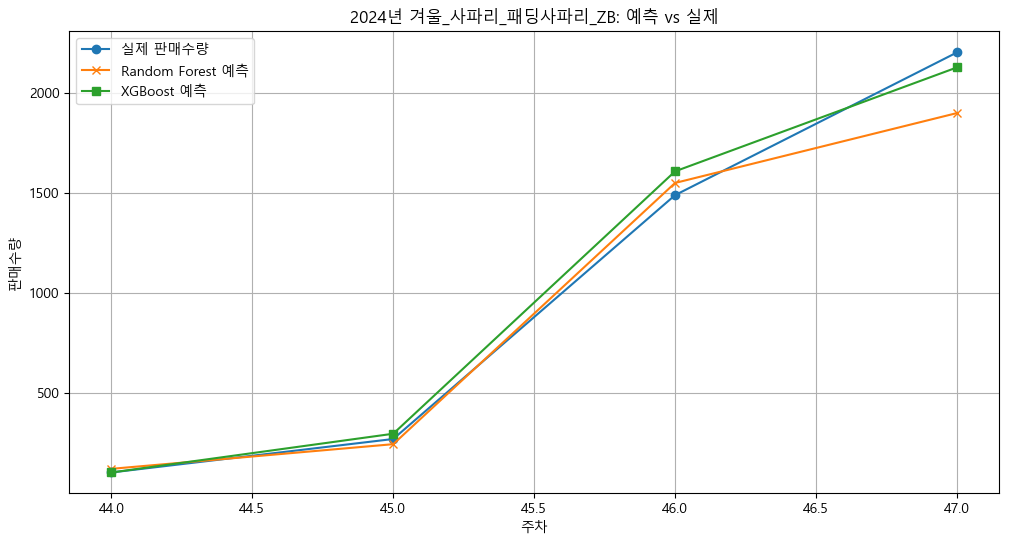

In [ ]:
target_df = model_df[
    (model_df['기획년도'] == 2024) &
    (model_df['주차'].between(44, 47)) &
    (model_df['카테고리'] == '겨울_사파리_패딩사파리_ZB')
]

X_target = target_df.drop(columns=['판매수량'])

y_actual = target_df['판매수량']

rf_preds = best_rf_model.predict(X_target)
xgb_preds = best_xgb_model.predict(X_target)

result_df = X_target.copy()
result_df['실제값'] = y_actual.values
result_df['RandomForest_예측값'] = rf_preds
result_df['XGBoost_예측값'] = xgb_preds

result_df = result_df.sort_values(by='주차').reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['주차'], result_df['실제값'], label='실제 판매수량', marker='o')
plt.plot(result_df['주차'], result_df['RandomForest_예측값'], label='Random Forest 예측', marker='x')
plt.plot(result_df['주차'], result_df['XGBoost_예측값'], label='XGBoost 예측', marker='s')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('2024년 겨울_사파리_패딩사파리_ZB: 예측 vs 실제')
plt.legend()
plt.grid(True)
plt.show()

## 6월시점

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

train_df = df[df['주차_날짜'] <= '2024-06-30']
test_df = df[(df['주차_날짜'] > '2024-06-30') & (df['주차_날짜']<='2024-07-28')]

train_df = train_df[columns]
test_df = test_df[columns]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

categorical_features = ['카테고리']
numerical_features = ['기획년도', '주차', '평균기온(도)', '할인율']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} 모델 성능:")
    print(f" - R^2: {r2:.4f}")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - MAE : {mae:.2f}")
    print('-' * 30)

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


Random Forest 모델 성능:
 - R^2: 0.7038
 - RMSE: 407.15
 - MAE : 204.83
------------------------------
XGBoost 모델 성능:
 - R^2: 0.7406
 - RMSE: 381.04
 - MAE : 212.71
------------------------------


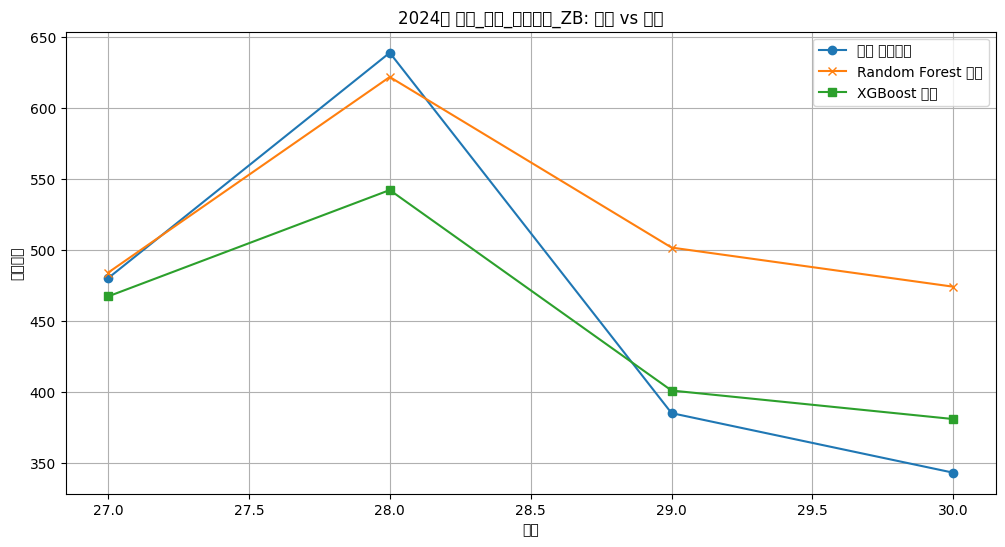

In [ ]:
target_df = model_df[
    (model_df['기획년도'] == 2024) &
    (model_df['주차'].between(27, 30)) &
    (model_df['카테고리'] == '사계절_수트_수트팬츠_ZB')
]

X_target = target_df.drop(columns=['판매수량'])

y_actual = target_df['판매수량']

rf_preds = rf_model.predict(X_target)
xgb_preds = xgb_model.predict(X_target)

result_df = X_target.copy()
result_df['실제값'] = y_actual.values
result_df['RandomForest_예측값'] = rf_preds
result_df['XGBoost_예측값'] = xgb_preds

result_df = result_df.sort_values(by='주차').reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['주차'], result_df['실제값'], label='실제 판매수량', marker='o')
plt.plot(result_df['주차'], result_df['RandomForest_예측값'], label='Random Forest 예측', marker='x')
plt.plot(result_df['주차'], result_df['XGBoost_예측값'], label='XGBoost 예측', marker='s')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('2024년 겨울_점퍼_패딩점퍼_ZB: 예측 vs 실제')
plt.legend()
plt.grid(True)
plt.show()